# Experiment 3
## Implementation of Searching Algorithms (BFS and DFS) in Python

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Algorithms for Intelligent Systems and Robotics Lab

### Aim
To implement Breadth First Search and Depth First Search in python and use them for traversal and path finding on a graph, and also on a grid map like a robot would use.

### Theory
**BFS** explores the graph level by level. It uses a queue, so all neighbours of a node are visited before going deeper. Because of this it gives the shortest path in terms of number of edges (unweighted graph).

**DFS** goes as deep as possible along one branch first and then backtracks. It uses a stack (or recursion, which is anyway using the call stack). The path it finds is not always shortest.

Both are uninformed search, means they dont use any heuristic about the goal.

Time complexity for both is O(V + E) and space is O(V).

## 1. Making the graph
Graph is stored as an adjacency list using a python dictionary.

In [1]:
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E', 'G'],
    'G': ['F']
}

for node in graph:
    print(node, ":", graph[node])

A : ['B', 'C']
B : ['A', 'D', 'E']
C : ['A', 'F']
D : ['B']
E : ['B', 'F']
F : ['C', 'E', 'G']
G : ['F']


In [2]:
print("total nodes =", len(graph))
print("total edges =", sum(len(v) for v in graph.values()) // 2)

total nodes = 7
total edges = 7


Just to see the graph once.

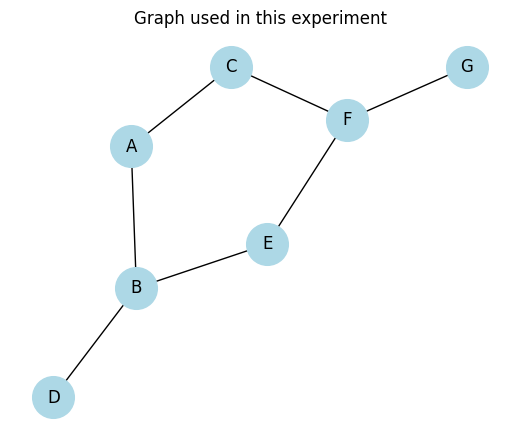

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
for node in graph:
    for nb in graph[node]:
        G.add_edge(node, nb)

plt.figure(figsize=(5,4))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=900, font_size=12)
plt.title("Graph used in this experiment")
plt.show()

## 2. Breadth First Search
Queue based. I used deque because popping from front of a normal list is slow.

In [22]:
from collections import deque

def bfs(graph, start):
    visited = []
    queue = deque([start])
    seen = {start}

    while queue:
        node = queue.popleft()
        visited.append(node)
        for nb in graph[node]:
            if nb not in seen:
                seen.add(nb)
                queue.append(nb)
    return visited

In [6]:
order = bfs(graph, 'A')
print("BFS order :", order)

BFS order : ['A', 'B', 'C', 'D', 'E', 'F', 'G']


To actually see the level by level nature i printed each level seperately.

In [7]:
def bfs_levels(graph, start):
    level = 0
    queue = deque([start])
    seen = {start}

    while queue:
        size = len(queue)
        current = []
        for i in range(size):
            node = queue.popleft()
            current.append(node)
            for nb in graph[node]:
                if nb not in seen:
                    seen.add(nb)
                    queue.append(nb)
        print("level", level, ":", current)
        level = level + 1

bfs_levels(graph, 'A')

level 0 : ['A']
level 1 : ['B', 'C']
level 2 : ['D', 'E', 'F']
level 3 : ['G']


## 3. Depth First Search
First the recursive one, it is the easiest to write.

In [9]:
def dfs_recursive(graph, node, visited=None):
    if visited is None:
        visited = []
    visited.append(node)
    for nb in graph[node]:
        if nb not in visited:
            dfs_recursive(graph, nb, visited)
    return visited

print("DFS (recursive) :", dfs_recursive(graph, 'A'))

DFS (recursive) : ['A', 'B', 'D', 'E', 'F', 'C', 'G']


Now the same thing with an explicit stack. Neighbours are reversed before pushing so that it picks them in the same order as the recursive version.

In [10]:
def dfs_iterative(graph, start):
    visited = []
    stack = [start]

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.append(node)
            for nb in reversed(graph[node]):
                if nb not in visited:
                    stack.append(nb)
    return visited

print("DFS (iterative) :", dfs_iterative(graph, 'A'))

DFS (iterative) : ['A', 'B', 'D', 'E', 'F', 'C', 'G']


In [11]:
print(bfs(graph, 'A'))
print(dfs_iterative(graph, 'A'))

['A', 'B', 'C', 'D', 'E', 'F', 'G']
['A', 'B', 'D', 'E', 'F', 'C', 'G']


## 4. Path finding between two nodes
Same algorithms but now i keep the whole path in the queue / stack instead of just the node.

In [13]:
def bfs_path(graph, start, goal):
    queue = deque([[start]])
    seen = {start}

    while queue:
        path = queue.popleft()
        node = path[-1]
        if node == goal:
            return path
        for nb in graph[node]:
            if nb not in seen:
                seen.add(nb)
                queue.append(path + [nb])
    return None


def dfs_path(graph, start, goal):
    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        node = path[-1]
        if node == goal:
            return path
        if node not in visited:
            visited.add(node)
            for nb in reversed(graph[node]):
                if nb not in visited:
                    stack.append(path + [nb])
    return None

In [14]:
p1 = bfs_path(graph, 'A', 'G')
p2 = dfs_path(graph, 'A', 'G')

print("BFS path :", p1, " length =", len(p1) - 1)
print("DFS path :", p2, " length =", len(p2) - 1)

BFS path : ['A', 'C', 'F', 'G']  length = 3
DFS path : ['A', 'B', 'E', 'F', 'G']  length = 4


BFS found it in 3 steps and DFS took 4, since DFS went into the B branch first. Tried one more pair below.

In [15]:
print("BFS :", bfs_path(graph, 'D', 'F'))
print("DFS :", dfs_path(graph, 'D', 'F'))

BFS : ['D', 'B', 'E', 'F']
DFS : ['D', 'B', 'A', 'C', 'F']


## 5. Search on a grid map (robot path planning)
This part is the actual robotics use. 0 is free space and 1 is an obstacle. The robot can move up, down, left, right. Each free cell is basically a node and neighbouring free cells are the edges, so the same BFS works here also.

In [16]:
import numpy as np

grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 0, 0, 0, 1, 0]
])

start = (0, 0)
goal = (7, 7)
print(grid)

[[0 0 0 0 0 0 0 0]
 [0 1 1 1 0 1 1 0]
 [0 0 0 1 0 0 0 0]
 [1 1 0 1 1 1 1 0]
 [0 0 0 0 0 0 1 0]
 [0 1 1 1 1 0 1 0]
 [0 0 0 0 1 0 0 0]
 [1 1 1 0 0 0 1 0]]


In [17]:
def neighbours(grid, cell):
    rows, cols = grid.shape
    r, c = cell
    moves = [(-1,0), (1,0), (0,-1), (0,1)]
    out = []
    for dr, dc in moves:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == 0:
            out.append((nr, nc))
    return out

print(neighbours(grid, (0,0)))

[(1, 0), (0, 1)]


In [18]:
def bfs_grid(grid, start, goal):
    queue = deque([[start]])
    seen = {start}
    explored = []

    while queue:
        path = queue.popleft()
        cell = path[-1]
        explored.append(cell)
        if cell == goal:
            return path, explored
        for nb in neighbours(grid, cell):
            if nb not in seen:
                seen.add(nb)
                queue.append(path + [nb])
    return None, explored


def dfs_grid(grid, start, goal):
    stack = [[start]]
    visited = set()
    explored = []

    while stack:
        path = stack.pop()
        cell = path[-1]
        if cell == goal:
            return path, explored
        if cell not in visited:
            visited.add(cell)
            explored.append(cell)
            for nb in reversed(neighbours(grid, cell)):
                if nb not in visited:
                    stack.append(path + [nb])
    return None, explored

In [19]:
bfs_p, bfs_seen = bfs_grid(grid, start, goal)
dfs_p, dfs_seen = dfs_grid(grid, start, goal)

print("BFS steps :", len(bfs_p) - 1, " cells explored :", len(bfs_seen))
print("DFS steps :", len(dfs_p) - 1, " cells explored :", len(dfs_seen))

BFS steps : 14  cells explored : 41
DFS steps : 20  cells explored : 40


In [20]:
print(bfs_p)

[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (4, 5), (5, 5), (6, 5), (6, 6), (6, 7), (7, 7)]


Plotting both paths on the map. White is free space, black is obstacle, blue is the path, green is start and red is goal.

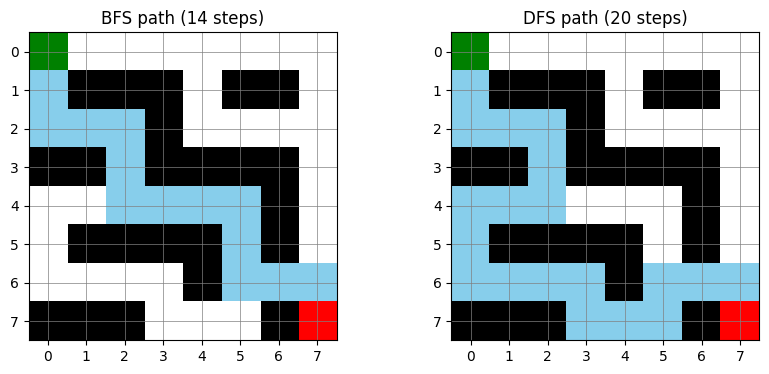

In [21]:
from matplotlib.colors import ListedColormap

# 0 free, 1 obstacle, 2 path, 3 start, 4 goal
cmap = ListedColormap(['white', 'black', 'skyblue', 'green', 'red'])

def show_path(grid, path, title):
    img = grid.copy()
    for cell in path:
        img[cell] = 2
    img[path[0]] = 3
    img[path[-1]] = 4

    plt.imshow(img, cmap=cmap, vmin=0, vmax=4)
    plt.title(title)
    plt.xticks(range(grid.shape[1]))
    plt.yticks(range(grid.shape[0]))
    plt.grid(color='gray', linewidth=0.5)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
show_path(grid, bfs_p, "BFS path (" + str(len(bfs_p)-1) + " steps)")
plt.subplot(1,2,2)
show_path(grid, dfs_p, "DFS path (" + str(len(dfs_p)-1) + " steps)")
plt.show()

## 6. Comparison

| | BFS | DFS |
|---|---|---|
| Data structure | Queue | Stack / recursion |
| Shortest path in unweighted graph | Yes | Not guaranteed |
| Memory | More, whole level is stored | Less, only one branch |
| Complete | Yes | Yes for finite graph |
| Time | O(V+E) | O(V+E) |

### Result
BFS and DFS were implemented in python and tested both on a graph and on a grid map. On the grid BFS reached the goal in 14 steps and DFS took 20, so DFS found a valid route but not the optimal one. Number of cells explored was almost same here (41 and 40) because the goal is in the far corner and BFS has to open up nearly the whole map before reaching it. So for a robot which needs the shortest route BFS is the right choice, DFS is only useful if any valid route is enough and memory is tight.

### Conclusion
Both are basicaly the same code, only difference is queue vs stack. Once i understood that the grid version was easy, a maze is just a graph where the cells are nodes.